# prediksi impor minyak mentah dari Dunia ke AS.


## Pendahuluan

Konsumsi energi dunia semakin meningkat seiring dengan pertumbuhan populasi dan industrialisasi. Minyak mentah merupakan salah satu sumber energi utama yang sangat penting bagi perekonomian global, terutama di negara-negara maju seperti Amerika Serikat. Impor minyak mentah menjadi salah satu indikator utama untuk mengetahui tingkat ketergantungan suatu negara terhadap sumber energi luar negeri, dan juga sebagai dasar untuk merumuskan kebijakan energi yang lebih baik. Data historis impor minyak mentah dari berbagai negara ke Amerika Serikat memberikan gambaran tentang tren kebutuhan energi dan hubungan perdagangan internasional di sektor energi.

Dalam penelitian ini, kami akan menganalisis tren impor minyak mentah Amerika Serikat dari berbagai negara, menggunakan data bulanan dalam ribuan barel. Pendekatan analisis menggunakan metode regresi untuk memprediksi pola impor di masa mendatang berdasarkan data historis yang ada. Hasil dari penelitian ini diharapkan dapat memberikan kontribusi dalam pengambilan kebijakan terkait energi di Amerika Serikat, khususnya dalam konteks ketahanan energi dan diversifikasi sumber impor.

### 1. Latar Belakang

Sejak dekade terakhir, Amerika Serikat telah berusaha untuk mengurangi ketergantungannya pada impor minyak mentah melalui peningkatan produksi domestik serta penggunaan energi alternatif. Meskipun demikian, impor minyak mentah tetap menjadi bagian penting dalam memenuhi kebutuhan energi nasional. Fluktuasi harga minyak global, kondisi geopolitik, serta perubahan dalam kebijakan energi domestik dan internasional memengaruhi volume impor minyak mentah. Dengan demikian, penting untuk memahami tren impor ini agar dapat mengantisipasi perubahan di masa depan serta menyusun strategi yang tepat untuk menjaga ketahanan energi.

Data impor minyak mentah memberikan wawasan tentang dinamika pasar energi dan bagaimana Amerika Serikat menyesuaikan kebutuhan energinya dengan pasokan global. Analisis tren impor minyak mentah juga dapat membantu dalam merumuskan kebijakan ekonomi dan lingkungan yang lebih baik, seperti pengurangan emisi karbon dan peralihan ke energi terbarukan.

### 2. Tujuan

1. Menganalisis tren impor minyak mentah ke Amerika Serikat dari berbagai negara.
2. Membuat prediksi terhadap volume impor minyak mentah di masa depan menggunakan metode regresi


### 3. Rumusan Masalah

1. Bagaimana tren impor minyak mentah ke Amerika Serikat dari tahun ke tahun?

2. Bagaimana prediksi volume impor minyak mentah di masa mendatang berdasarkan data historis?


## Pembahasan

### 1. Data Understanding

#### Pengumpulan Data

In [93]:
import pandas as pd

# Load dataset
file_path = open('Imports Oil.csv')
data = pd.read_csv(file_path)
print(data.head())

  Date and Month  \
0       2009 01    
1       2009 02    
2       2009 03    
3       2009 04    
4       2009 05    

   Crude oil imports from the World to the US (a thousand barrels)  
0                                             317275                
1                                             262339                
2                                             303897                
3                                             285934                
4                                             281147                


##### Struktur Data:

1. Date and Month : Menunjukkan kapan impor minyak mentah terjadi, dengan format tahun dan bulan (misalnya, "2009 01" untuk Januari 2009).
2. Crude oil imports from the World to the US (a thousand barrels) : Volume minyak mentah yang diimpor ke AS dalam ribuan barel untuk setiap bulan yang bersangkutan. Angka ini menggambarkan total impor dari seluruh dunia ke Amerika Serikat.

#### 2. Data Preprocessing

Pada bagian ini dataset akan diproses sebelum digunakan untuk membangun model. Dataset akan melalui data cleaning, pendeteksian outlier, dan pendeteksian missing value.

In [94]:
# Tahap 1: Pembersihan nama kolom dari spasi yang tidak perlu
data.columns = data.columns.str.strip()

In [95]:
# Tahap 2: Pendeteksian nilai yang hilang (missing values)
missing_values = data.isnull().sum()
print("Jumlah missing value per kolom:")
print(missing_values)

Jumlah missing value per kolom:
Date and Month                                                     0
Crude oil imports from the World to the US (a thousand barrels)    0
dtype: int64


In [96]:
# Tahap 3: Pendeteksian Outlier menggunakan metode IQR
# Menghitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga)
Q1 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.25)
Q3 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi nilai outlier
outliers = data[(data['Crude oil imports from the World to the US (a thousand barrels)'] < lower_bound) |
                (data['Crude oil imports from the World to the US (a thousand barrels)'] > upper_bound)]

# Menampilkan hasil deteksi outlier
if outliers.empty:
    print("Tidak ada outlier yang terdeteksi.")
else:
    print("Outlier yang terdeteksi:")
    print(outliers)

Tidak ada outlier yang terdeteksi.


In [97]:
# Tahap 1: Pembersihan nama kolom dari spasi yang tidak perlu
data.columns = data.columns.str.strip()

# Tahap 2: Pendeteksian nilai yang hilang (missing values)
missing_values = data.isnull().sum()
print("Jumlah missing value per kolom:")
print(missing_values)

# Tahap 3: Pendeteksian Outlier menggunakan metode IQR
# Menghitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga)
Q1 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.25)
Q3 = data['Crude oil imports from the World to the US (a thousand barrels)'].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi nilai outlier
outliers = data[(data['Crude oil imports from the World to the US (a thousand barrels)'] < lower_bound) |
                (data['Crude oil imports from the World to the US (a thousand barrels)'] > upper_bound)]

# Menampilkan hasil deteksi outlier
if outliers.empty:
    print("Tidak ada outlier yang terdeteksi.")
else:
    print("Outlier yang terdeteksi:")
    print(outliers)


Jumlah missing value per kolom:
Date and Month                                                     0
Crude oil imports from the World to the US (a thousand barrels)    0
dtype: int64
Tidak ada outlier yang terdeteksi.


In [98]:
# Menghitung matriks korelasi
correlation_matrix = data[['Crude oil imports from the World to the US (a thousand barrels)']].corr()

# Menampilkan matriks korelasi
print("Matriks Korelasi:")
print(correlation_matrix)


Matriks Korelasi:
                                                    Crude oil imports from the World to the US (a thousand barrels)
Crude oil imports from the World to the US (a t...                                                1.0              


#### Sliding Window

In [99]:
import pandas as pd

# Fungsi untuk membuat sliding window
def create_sliding_window(data, window_size=4):
    # Mengambil data impor minyak mentah dan tanggal
    oil_imports = data['Crude oil imports from the World to the US (a thousand barrels)']
    dates = data['Date and Month']

    # Membuat list untuk menampung windows
    windows = []
    window_dates = []

    # Loop untuk membuat sliding window
    for i in range(len(oil_imports) - window_size + 1):
        windows.append(oil_imports[i:i + window_size].values)
        window_dates.append(dates[i + window_size - 1])  # Ambil tanggal akhir dari window

    # Membuat DataFrame dengan index berupa tanggal
    df_sliding_windows = pd.DataFrame(windows, columns=[f'Window_{i+1}' for i in range(window_size)], index=window_dates)
    df_sliding_windows.index.name = 'Date'  # Menamai index
    return df_sliding_windows

# Membuat sliding window dengan ukuran 3
df_sliding_windows = create_sliding_window(data, window_size=4)

# Menampilkan DataFrame
print(df_sliding_windows)  # Menampilkan contoh 5 baris pertama dari sliding windows


          Window_1  Window_2  Window_3  Window_4
Date                                            
2009 04     317275    262339    303897    285934
2009 05     262339    303897    285934    281147
2009 06     303897    285934    281147    284093
2009 07     285934    281147    284093    287569
2009 08     281147    284093    287569    279111
...            ...       ...       ...       ...
2020 09     191919    183087    168406    161926
2020 10     183087    168406    161926    164494
2020 11     168406    161926    164494    168655
2020 12     161926    164494    168655    178597
2021 01     164494    168655    178597    181197

[142 rows x 4 columns]


In [100]:
print(df_sliding_windows.index)  # Untuk memastikan index

Index(['2009 04 ', '2009 05 ', '2009 06 ', '2009 07 ', '2009 08 ', '2009 09 ',
       '2009 10 ', '2009 11 ', '2009 12 ', '2010 01 ',
       ...
       '2020 04 ', '2020 05 ', '2020 06 ', '2020 07 ', '2020 08 ', '2020 09 ',
       '2020 10 ', '2020 11 ', '2020 12 ', '2021 01 '],
      dtype='object', name='Date', length=142)


Fungsi create_sliding_window:
window_size: Menentukan ukuran jendela
Looping digunakan untuk mengambil subset data dalam ukuran jendela yang ditentukan, dan jendela bergerak maju satu data dalam setiap iterasi.

#### Visualisasi data

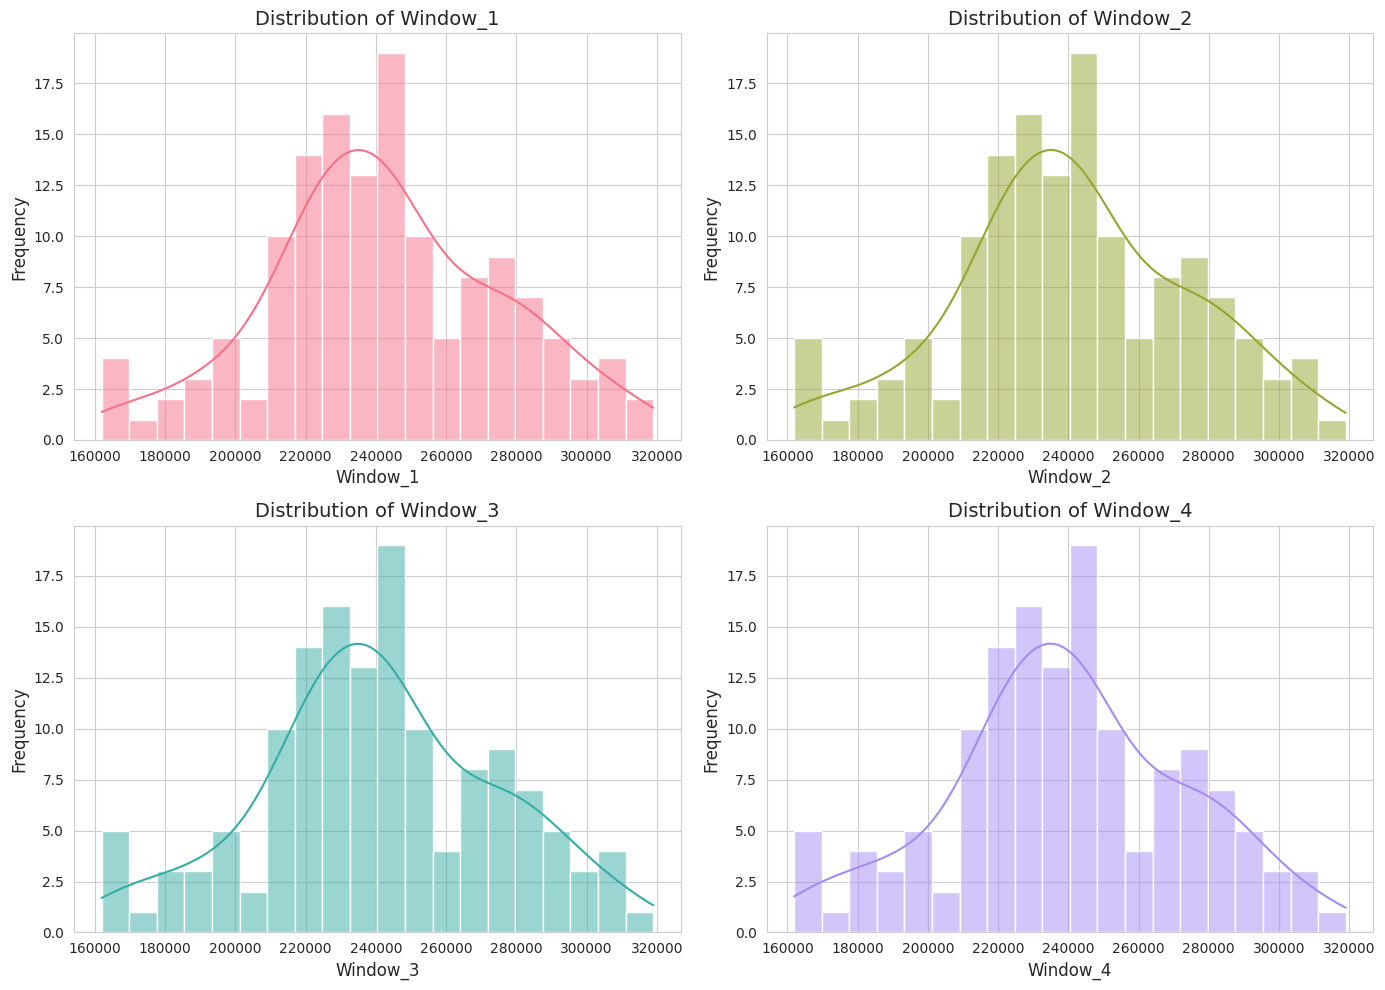

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengambil semua kolom fitur
features = list(df_sliding_windows.columns)

# Menghitung jumlah subplot yang diperlukan
num_features = len(features)
num_rows = (num_features + 1) // 2  # Pembulatan ke atas untuk jumlah baris

# Mengatur gaya seaborn untuk tampilan lebih menarik
sns.set_style("whitegrid")

# Membuat subplot sesuai dengan jumlah fitur
fig, axs = plt.subplots(num_rows, 2, figsize=(14, num_rows * 5))

# Membuat palet warna yang berbeda untuk setiap histogram
colors = sns.color_palette("husl", num_features)

# Melakukan plotting untuk setiap fitur
for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    sns.histplot(df_sliding_windows[feature], bins=20, color=colors[i], ax=axs[row, col], kde=True)
    axs[row, col].set_title(f'Distribution of {feature}', fontsize=14)
    axs[row, col].set_xlabel(feature, fontsize=12)
    axs[row, col].set_ylabel('Frequency', fontsize=12)
    axs[row, col].tick_params(axis='both', which='major', labelsize=10)

# Menghapus subplot yang tidak terpakai jika jumlah fitur ganjil
if num_features % 2 == 1:
    fig.delaxes(axs[num_rows - 1, 1])

# Menyesuaikan layout agar tidak saling tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()


<Axes: xlabel='Date'>

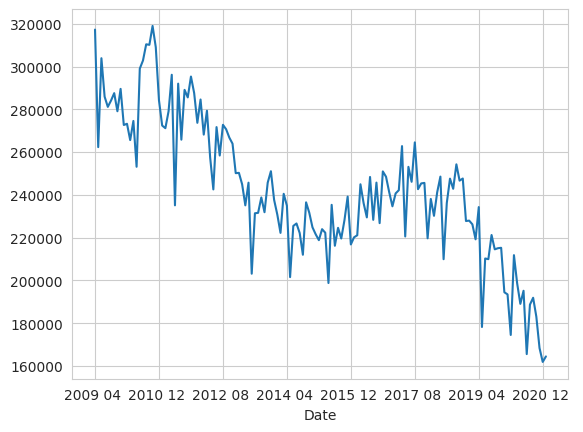

In [102]:
df_sliding_windows['Window_1'].plot()

#### deteksi missing value

In [103]:
print(df_sliding_windows.isnull().sum())

Window_1    0
Window_2    0
Window_3    0
Window_4    0
dtype: int64


#### Pendeteksian Outlier

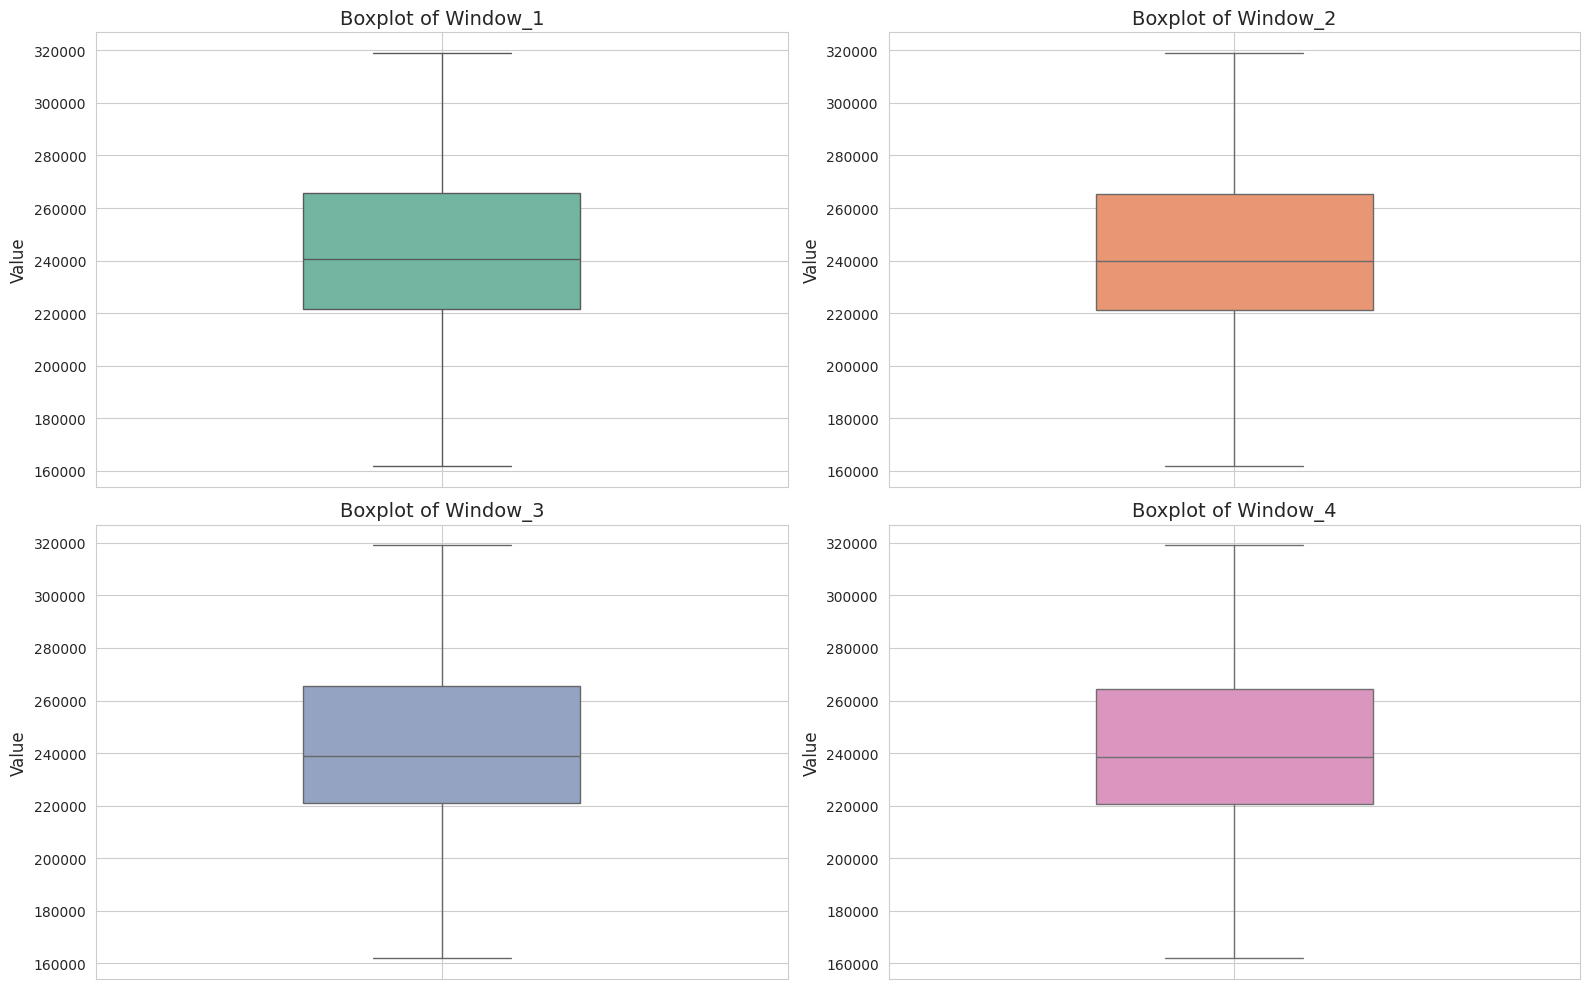

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Daftar kolom fitur yang akan digunakan
features = ['Window_1', 'Window_2', 'Window_3', 'Window_4']

# Mengatur ukuran figure
plt.figure(figsize=(16, 10))

# Menggunakan palet warna dari seaborn
colors = sb.color_palette("Set2", len(features))

# Membuat subplot untuk setiap fitur
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)

    # Membuat boxplot untuk tiap fitur
    sb.boxplot(data=df_sliding_windows[col], color=colors[i], width=0.4)

    # Memberikan judul yang jelas pada tiap plot
    plt.title(f'Boxplot of {col}', fontsize=14)

    # Memberikan label yang lebih jelas pada sumbu y
    plt.ylabel('Value', fontsize=12)

    # Menambahkan grid pada tiap plot untuk mempermudah pembacaan
    plt.grid(True)

# Menyesuaikan layout agar tidak terlalu padat
plt.tight_layout()

# Menampilkan plot
plt.show()


In [105]:
import numpy as np
import pandas as pd

# Menghitung IQR dan menghapus outlier
def remove_outliers(df, features):
    df_clean = df.copy()  # Membuat salinan agar data asli tidak terpengaruh

    for col in features:
        # Menghitung Q1, Q3 dan IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        # Menentukan batas untuk outlier
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Hapus outlier
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

# Fitur yang ingin dideteksi outlier dan dibersihkan
features = ['Window_1', 'Window_2', 'Window_3', 'Window_4']

# Menerapkan fungsi penghapusan outlier
df_slide_cleaned = remove_outliers(df_sliding_windows, features)

# Tampilkan data yang telah dibersihkan
print("Data yang telah dibersihkan dari outlier:")
print(df_slide_cleaned)


Data yang telah dibersihkan dari outlier:
          Window_1  Window_2  Window_3  Window_4
Date                                            
2009 04     317275    262339    303897    285934
2009 05     262339    303897    285934    281147
2009 06     303897    285934    281147    284093
2009 07     285934    281147    284093    287569
2009 08     281147    284093    287569    279111
...            ...       ...       ...       ...
2020 09     191919    183087    168406    161926
2020 10     183087    168406    161926    164494
2020 11     168406    161926    164494    168655
2020 12     161926    164494    168655    178597
2021 01     164494    168655    178597    181197

[142 rows x 4 columns]


#### normalisasi data

In [106]:
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi semua kolom kecuali indeks
df_normalisasi = pd.DataFrame(scaler.fit_transform(df_slide_cleaned), columns=df_slide_cleaned.columns, index=df_slide_cleaned.index)
print(df_normalisasi)

          Window_1  Window_2  Window_3  Window_4
Date                                            
2009 04   0.989075  0.639309  0.903900  0.789533
2009 05   0.639309  0.903900  0.789533  0.759055
2009 06   0.903900  0.789533  0.759055  0.777812
2009 07   0.789533  0.759055  0.777812  0.799943
2009 08   0.759055  0.777812  0.799943  0.746092
...            ...       ...       ...       ...
2020 09   0.190959  0.134728  0.041257  0.000000
2020 10   0.134728  0.041257  0.000000  0.016350
2020 11   0.041257  0.000000  0.016350  0.042842
2020 12   0.000000  0.016350  0.042842  0.106141
2021 01   0.016350  0.042842  0.106141  0.122694

[142 rows x 4 columns]


### 3. Modeling

#### membagi data

In [107]:
from sklearn.model_selection import train_test_split

# Pastikan df_normalisasi sudah terdefinisi dan berisi data yang diperlukan

# Mengambil fitur (X) dengan menghapus kolom target (Window_1)
X_train_model = df_normalisasi.drop(columns=['Window_1'])

# Mengambil kolom target (y) yaitu Window_1
y_train_model = df_normalisasi['Window_1']

# Memisahkan data menjadi data latih dan data uji
# Menggunakan test_size=0.2 untuk 20% data sebagai data uji
# shuffle=False agar data tetap dalam urutan waktu (jika relevan)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_model,
    y_train_model,
    test_size=0.1,
    random_state=42,
    shuffle=False
)

# Menampilkan ukuran dari data latih dan data uji untuk verifikasi
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


X_train shape: (127, 3)
X_test shape: (15, 3)
y_train shape: (127,)
y_test shape: (15,)


 memiliki total 142 data poin dalam dataset awal (113 untuk pelatihan dan 29 untuk pengujian).
Pemisahan data dilakukan dengan proporsi 80% untuk pelatihan dan 20% untuk pengujian, yang merupakan praktik umum dalam pembelajaran mesin.

#### Membangun Model

##### Linear Regression

Mean Squared Error: 0.009429088899266691
R-squared: 0.0947443885219631
            Actual  Predicted
Date                         
2019 11   0.339649   0.223963
2019 12   0.207296   0.195499
2020 01   0.200980   0.269334
2020 02   0.080253   0.283567
2020 03   0.317773   0.235683
2020 04   0.233897   0.211875
2020 05   0.172757   0.149194
2020 06   0.211728   0.174184
2020 07   0.023302   0.216599
2020 08   0.170420   0.180929
2020 09   0.190959   0.113112
2020 10   0.134728   0.069346
2020 11   0.041257   0.070004
2020 12   0.000000   0.096622
2021 01   0.016350   0.137782


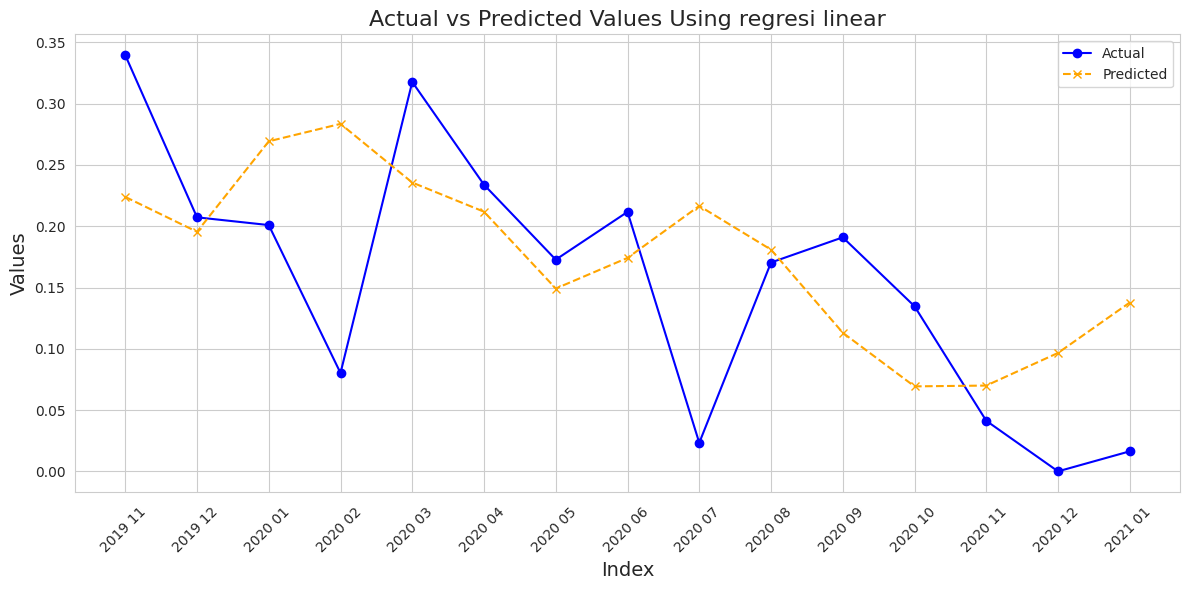

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Inisialisasi dan latih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Tampilkan hasil prediksi vs aktual
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
print(results)

# Plot hasil
plt.figure(figsize=(12, 6))
plt.plot(results.index, results['Actual'], marker='o', linestyle='-', color='blue', label='Actual')
plt.plot(results.index, results['Predicted'], marker='x', linestyle='--', color='orange', label='Predicted')

# Menambahkan label dan judul
plt.title('Actual vs Predicted Values Using regresi linear', fontsize=16)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.legend()
plt.grid(True)

# Menampilkan plot
plt.xticks(rotation=45)  # Memutar label sumbu x agar lebih mudah dibaca
plt.tight_layout()  # Mengatur layout agar tidak bertabrakan
plt.show()


##### Random Forest

Mean Squared Error: 0.04220431151393445
R-squared: -3.0518962367114364
            Actual  Predicted
Date                         
2019 11   0.339649   0.320203
2019 12   0.207296   0.330321
2020 01   0.200980   0.384523
2020 02   0.080253   0.278209
2020 03   0.317773   0.306679
2020 04   0.233897   0.327519
2020 05   0.172757   0.322213
2020 06   0.211728   0.340151
2020 07   0.023302   0.327519
2020 08   0.170420   0.329267
2020 09   0.190959   0.341979
2020 10   0.134728   0.341979
2020 11   0.041257   0.341979
2020 12   0.000000   0.341979
2021 01   0.016350   0.341979


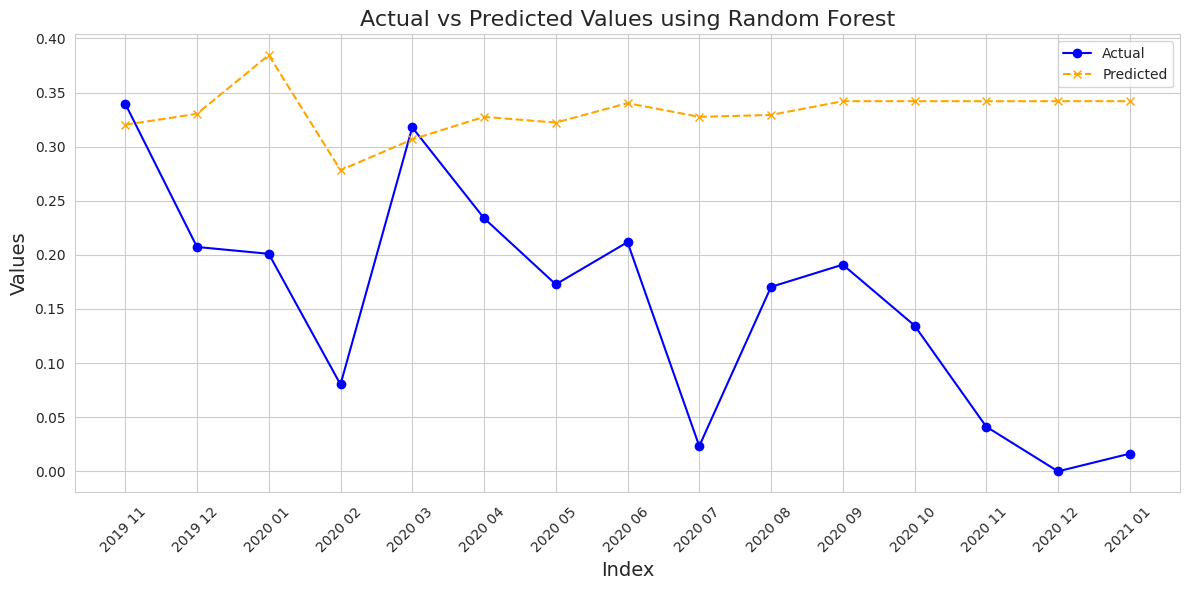

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Inisialisasi dan latih model Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Tampilkan hasil prediksi vs aktual
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
print(results)

# Plot hasil
plt.figure(figsize=(12, 6))
plt.plot(results.index, results['Actual'], marker='o', linestyle='-', color='blue', label='Actual')
plt.plot(results.index, results['Predicted'], marker='x', linestyle='--', color='orange', label='Predicted')

# Menambahkan label dan judul
plt.title('Actual vs Predicted Values using Random Forest', fontsize=16)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.legend()
plt.grid(True)

# Menampilkan plot
plt.xticks(rotation=45)  # Memutar label sumbu x agar lebih mudah dibaca
plt.tight_layout()  # Mengatur layout agar tidak bertabrakan
plt.show()


##### LSTM

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - loss: 0.2988 - val_loss: 0.2788
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2770 - val_loss: 0.2526
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2474 - val_loss: 0.2257
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2086 - val_loss: 0.1975
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1827 - val_loss: 0.1678
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1417 - val_loss: 0.1372
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1326 - val_loss: 0.1061
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0945 - val_loss: 0.0765
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0689 - val_loss: 0.0506
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0467 - val_loss: 0.0308
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0195
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0202 - val_l

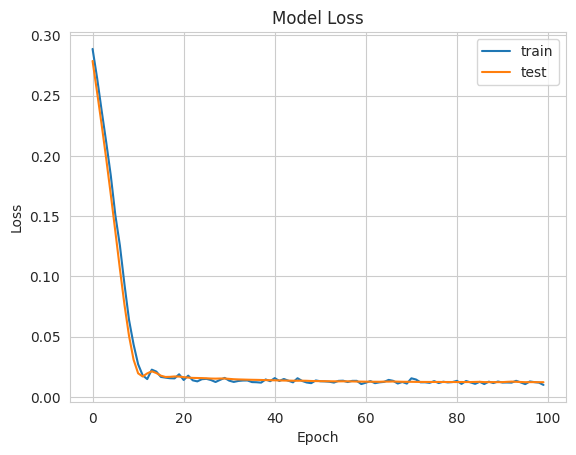

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape input data for LSTM
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Membangun model LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mse')

# Train the model
history = model_lstm.fit(X_train_lstm, y_train, epochs=100, batch_size=32, validation_data=(X_test_lstm, y_test), verbose=1)

# Make predictions
y_pred = model_lstm.predict(X_test_lstm)

# Flatten predictions for comparison
y_pred_flat = y_pred.flatten()

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_flat)
r2 = r2_score(y_test, y_pred_flat)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Plot training and validation loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


### 4. Bagging Ensemble Learning

In [111]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import matplotlib.pyplot as plt

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse
# Assuming df_normalized is already loaded
X = df_normalisasi[['Window_2', 'Window_3', 'Window_4']]
y = df_normalisasi['Window_1']  # Variabel target

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



#### regresi linier

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Inisialisasi dan latih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Tampilkan hasil prediksi vs aktual
# results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
# print(results)

Mean Squared Error: 0.012193946879073818
R-squared: 0.7108709775493947


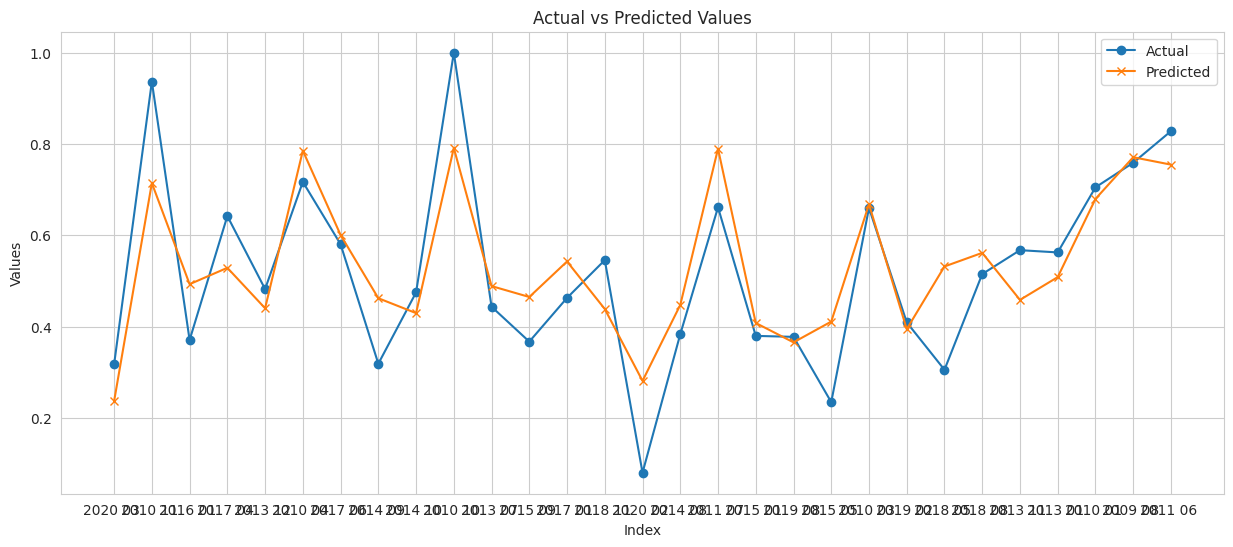

In [113]:
# Create a DataFrame to hold the actual vs predicted results
results_regresion = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Plotting the Actual vs Predicted values
plt.figure(figsize=(15,6))
plt.plot(results_regresion.index, results_regresion['Actual'], label='Actual', marker='o')
plt.plot(results_regresion.index, results_regresion['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

#### random forest

In [114]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi dan latih model Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Tampilkan hasil prediksi vs aktual
# results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
# print(results)

Mean Squared Error: 0.014783710486354205
R-squared: 0.6494654435105254


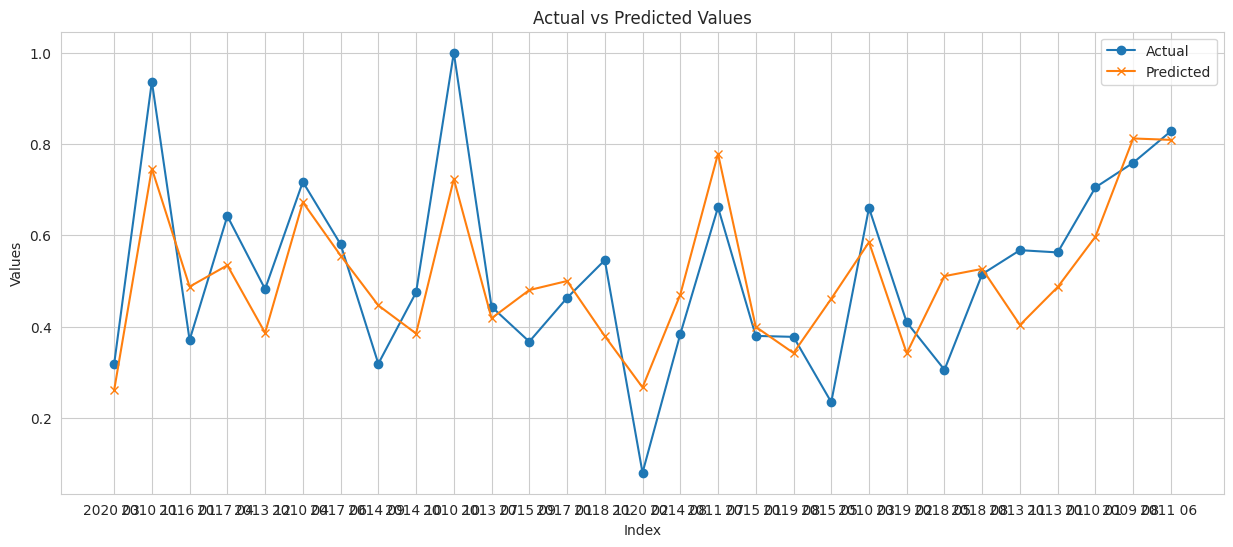

In [115]:
# Create a DataFrame to hold the actual vs predicted results
results_forest = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Plotting the Actual vs Predicted values
plt.figure(figsize=(15,6))
plt.plot(results_forest.index, results_forest['Actual'], label='Actual', marker='o')
plt.plot(results_forest.index, results_forest['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

#### LSTM

In [116]:
# Import library tambahan untuk menghitung R-squared
from sklearn.metrics import mean_squared_error, r2_score

# Mengubah bentuk data untuk LSTM
X_train_lstm = np.array(X_train).reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = np.array(X_test).reshape((X_test.shape[0], X_test.shape[1], 1))

# Model LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Melatih model LSTM
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)

# Prediksi menggunakan LSTM
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Menghitung Mean Squared Error (MSE)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)

# Menghitung R-squared
r2_lstm = r2_score(y_test, y_pred_lstm)

# Menampilkan hasil MSE dan R-squared
print(f'Mean Squared Error: {mse_lstm}')
print(f'R-squared: {r2_lstm}')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Mean Squared Error: 0.08283154476912014
R-squared: -0.964007536252961


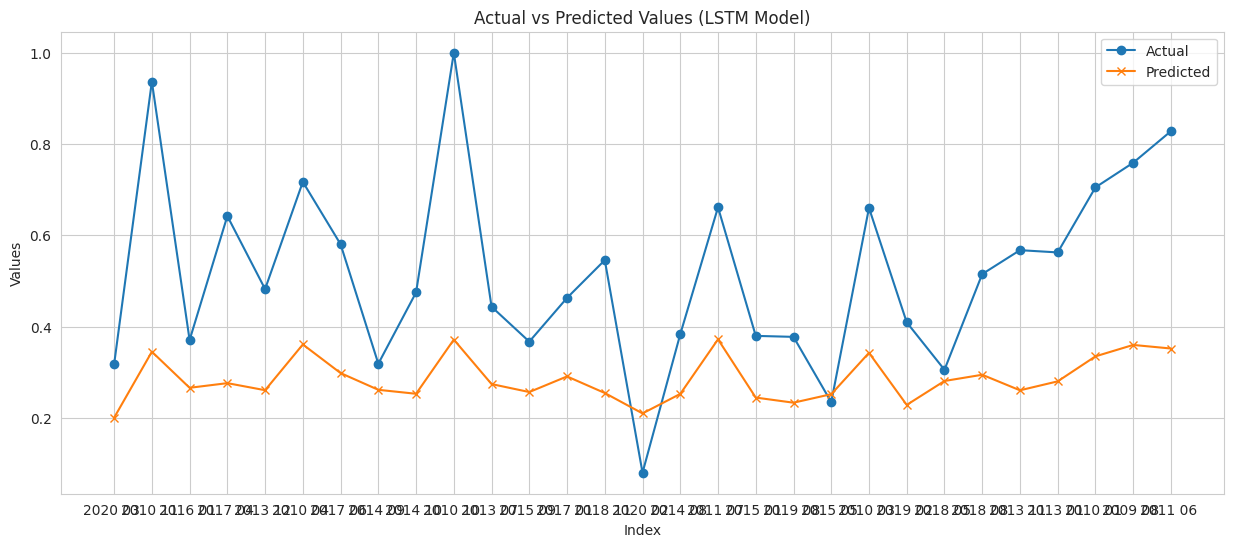

In [117]:
# Membuat DataFrame untuk menyimpan hasil aktual vs prediksi dari model LSTM
results_lstm = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lstm}, index=y_test.index)

# Plot nilai aktual vs prediksi
plt.figure(figsize=(15,6))
plt.plot(results_lstm.index, results_lstm['Actual'], label='Actual', marker='o')
plt.plot(results_lstm.index, results_lstm['Predicted'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Values (LSTM Model)')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Tampilkan plot
plt.show()


### 5. Deployment

##### Linear Regression Tunggal

In [118]:
# Import pustaka yang diperlukan
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

# Asumsikan df_normalisasi adalah dataframe yang sudah dinormalisasi
# Pisahkan dataset menjadi fitur (X) dan target (y)
X = df_normalisasi.drop('Window_1', axis=1)  # Ganti 'Window_1' dengan nama kolom target yang sebenarnya
y = df_normalisasi['Window_1']

# Bagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi model dasar (Linear Regression)
model_dasar = RandomForestRegressor()

# Buat model ensemble Bagging menggunakan model dasar
# Mengubah 'base_estimator' menjadi 'estimator'
model_bagging = BaggingRegressor(estimator=model_dasar, n_estimators=10, random_state=42)

# Latih model
model_bagging.fit(X_train, y_train)

# Buat prediksi
y_pred = model_bagging.predict(X_test)

# Hitung dan cetak kinerja model menggunakan Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 0.011995057113889563


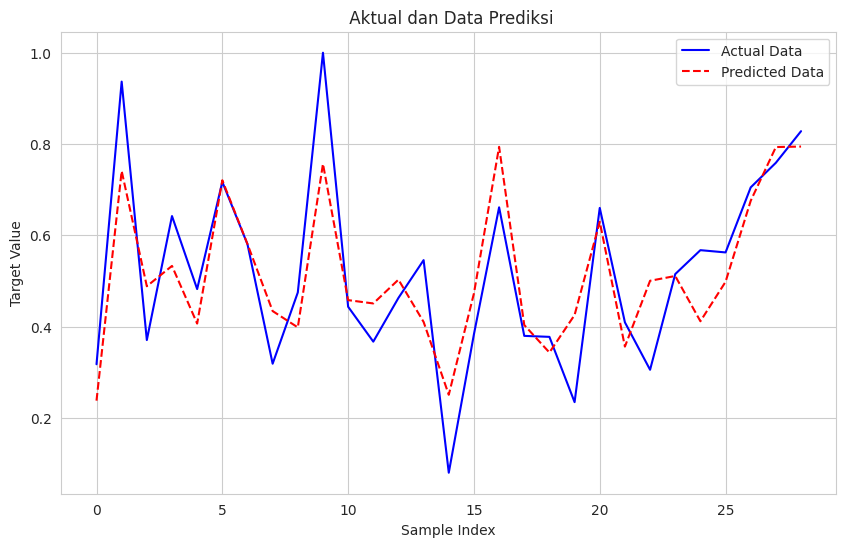

In [119]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt

# Create a plot to visualize the actual vs predicted data
plt.figure(figsize=(10,6))

# Plot the actual data
plt.plot(y_test.values, label='Actual Data', color='blue')

# Plot the predicted data
plt.plot(y_pred, label='Predicted Data', color='red', linestyle='--')

# Add titles and labels
plt.title(' Aktual dan Data Prediksi')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')

# Add a legend to differentiate between actual and predicted data
plt.legend()

# Show the plot
plt.show()
